## NAME: Odilon Ligan & Nick Snyder



#  Bucknell Lending Decision Engine

## Objective
The goal of this project is to build a data-driven system to evaluate loan applications by:

1. Predicting the **expected return** of a loan (regression task)
2. Estimating the **probability of default** (classification task)
3. Combining both to make a **risk-adjusted lending decision**

## Key Idea
Rather than focusing purely on prediction accuracy, this system is designed to:
- **Rank loans effectively**
- **Improve selection decisions**
- **Maximize risk-adjusted returns**

This reflects real-world lending, where decisions are based on **risk vs reward trade-offs**, not perfect prediction.

---

## Modeling Approach
We combine:
- **Lasso Regression** → Predict expected return  
- **Logistic Regression** → Estimate default probability  

Final decision is based on:
- Probability threshold (risk control)
- Risk-adjusted score

---

## Evaluation Philosophy
We evaluate models based on:
- **Top-K selection performance**
- **Return improvement vs random selection**

This aligns with real investment decision-making.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.pipeline import Pipeline
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import joblib

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 20)

## Data Loading

We begin by loading the Lending Club dataset, which contains historical loan performance.

This dataset includes:

- Borrower characteristics (income, FICO, DTI)
- Loan attributes (amount, interest rate, term)
- Outcomes (fully paid, charged off)

This serves as the foundation for both:
- Return prediction
- Default classification

In [3]:
# Load the dataset

# load data set from https://raw.githubusercontent.com/MattDBailey/ANOP330/refs/heads/main/Data/BucknellLendingClubHistoricalData.csv
df = pd.read_csv('https://raw.githubusercontent.com/MattDBailey/ANOP330/refs/heads/main/Data/BucknellLendingClubHistoricalData.csv')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (50000, 29)


,id,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,...,fico_range_high,fico_range_low,revol_bal,revol_util,total_pymnt,last_pymnt_d,recoveries,loan_length,term_num,ret_PESS
0,44756846,10000,10000,36 months,9.9,322.63,B,10+ years,MORTGAGE,43717.0,...,794,790,59708,19.0,11485.6780,2017-06-01,0.0,26.021069,36,4.952260
1,99480680,34050,34050,60 months,28.6,1074.40,F,10+ years,MORTGAGE,85000.0,...,699,695,16779,76.0,41436.5400,2017-12-01,0.0,9.035093,60,4.338643
2,88321792,9600,9600,36 months,10.4,311.98,B,< 1 year,OWN,37000.0,...,684,680,10148,48.0,10528.5460,2017-09-01,0.0,13.010534,36,3.224118
3,58401079,5000,5000,36 months,9.9,161.32,B,3 years,MORTGAGE,120000.0,...,674,670,14607,38.0,5480.6100,2016-10-01,0.0,13.010534,36,3.204066
4,92749250,9000,9000,36 months,17.9,325.33,D,< 1 year,RENT,70000.0,...,664,660,5344,66.0,10473.4795,2017-11-01,0.0,11.992033,36,5.457331


In [4]:
 #Quick EDA report
def report(df):
    col, d_type, uniques, n_uniques, n_nulls, size = [], [], [], [], [], []
    for i in df.columns:
        col.append(i)
        d_type.append(df[i].dtypes)
        uniques.append(df[i].unique()[:5])
        n_uniques.append(df[i].nunique())
        n_nulls.append(df[i].isnull().sum())
        size.append(df[i].size)
    return pd.DataFrame({'Column': col, 'd_type': d_type, 'unique_sample': uniques,
                         'n_uniques': n_uniques, 'n_nulls': n_nulls, 'size': size})

pd.set_option('display.max_rows', 50)
report(df)

,Column,d_type,unique_sample,n_uniques,n_nulls,size
0,id,int64,"[44756846, 99480680, 88321792, 58401079, 92749...",50000,0,50000
1,loan_amnt,int64,"[10000, 34050, 9600, 5000, 9000]",1298,0,50000
2,funded_amnt,int64,"[10000, 34050, 9600, 5000, 9000]",1299,0,50000
3,term,object,"[ 36 months, 60 months]",2,0,50000
4,int_rate,float64,"[9.9, 28.6, 10.4, 17.9, 20.9]",220,0,50000
5,installment,float64,"[322.63, 1074.4, 311.98, 161.32, 325.33]",19095,0,50000
6,grade,object,"[B, F, D, E, A]",7,0,50000
7,emp_length,object,"[10+ years, < 1 year, 3 years, 8 years, 2 years]",11,2908,50000
8,home_ownership,object,"[MORTGAGE, OWN, RENT, ANY, OTHER]",6,0,50000
9,annual_inc,float64,"[43717.0, 85000.0, 37000.0, 120000.0, 70000.0]",5063,0,50000


##  What this cell is doing

This cell removes unnecessary or irrelevant columns from the dataset.

Why this is done:
- Reduces noise and dimensionality
- Removes leakage variables (future info that would not be available at prediction time)
- Improves model generalization

Key idea:
Only keep features that are available at loan approval time and useful for prediction.


---

##  Key takeaway
This step contributes to building a reliable pipeline for predicting loan risk and return.

In [5]:
#Remove Leakage & Useless Columns
drop_cols = [
    "id",
    "funded_amnt",
    "total_pymnt",
    "recoveries",
    "last_pymnt_d",
    "loan_length",
    "term"
]

df = df.drop(columns=drop_cols, errors='ignore')
df.shape

(50000, 22)

### 📊 Exploratory Data Analysis: Target & Return Distributions

In this section, we explore the distribution of key target variables to better understand the structure of the dataset and inform modeling decisions.

For instance:

#### 🔹 Loan Status Distribution
We examine the balance between **Fully Paid** and **Charged Off** loans. This helps identify potential **class imbalance**, which is critical for classification tasks and may impact model performance (for example, bias toward the majority class).

#### 🔹 Return Distribution (`ret_PESS`)
We visualize the distribution of realized loan returns to understand:
- The overall spread and variability  
- Presence of skewness or extreme values  
- Whether returns are centered around positive or negative values  

#### 💡 Why this matters
- Class imbalance influences which evaluation metrics to prioritize (precision, recall vs accuracy)  
- Return distribution informs regression modeling and risk analysis  
- These insights guide **feature engineering**, **model selection**, and **threshold decisions**

loan_status
Fully Paid     39987
Charged Off    10013
Name: count, dtype: int64


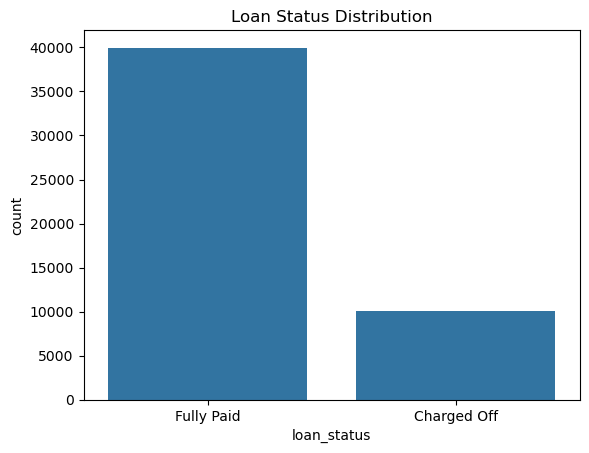

In [6]:
#Explore Target Distributions
print(df["loan_status"].value_counts())
sns.countplot(x="loan_status", data=df)
plt.title("Loan Status Distribution")
plt.show()

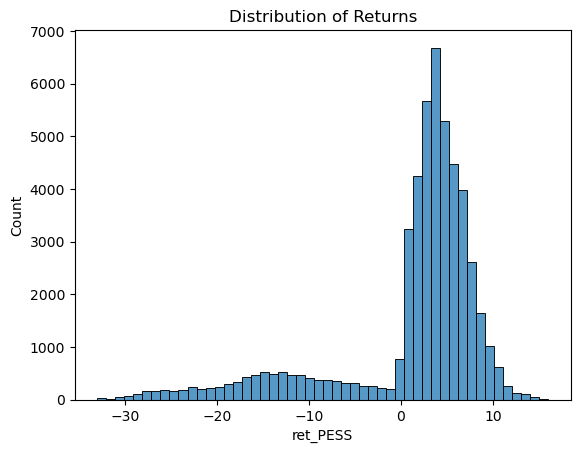

In [7]:
sns.histplot(df["ret_PESS"], bins=50)
plt.title("Distribution of Returns")
plt.show()

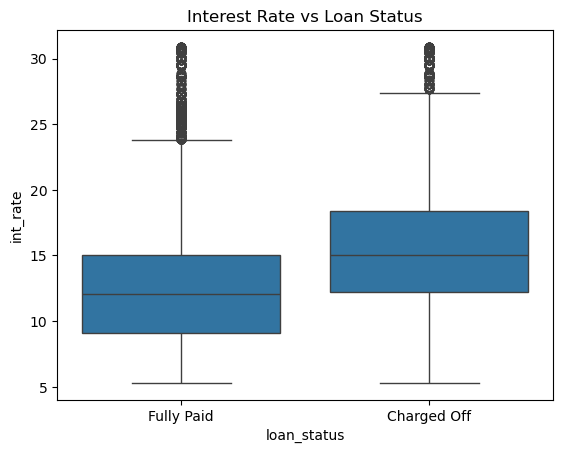

In [8]:
#RELATIONSHIP EXPLORATION
sns.boxplot(x="loan_status", y="int_rate", data=df)
plt.title("Interest Rate vs Loan Status")
plt.show()

*   Higher interest loans default more
*   Suggests risk-based pricing


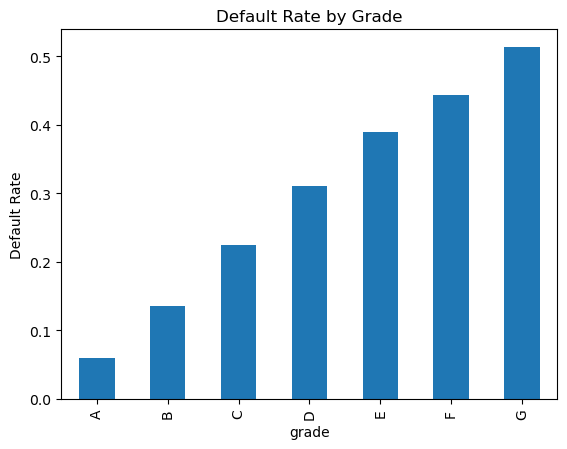

In [9]:
default_rate = df.groupby("grade")["loan_status"].apply(
    lambda x: (x == "Charged Off").mean()
)
default_rate.plot(kind="bar")
plt.title("Default Rate by Grade")
plt.ylabel("Default Rate")
plt.show()

*   Lower grades (E, F, G) : much higher default rates
*   shows that lower grades have relatively more charged-off loans compared to fully paid loans

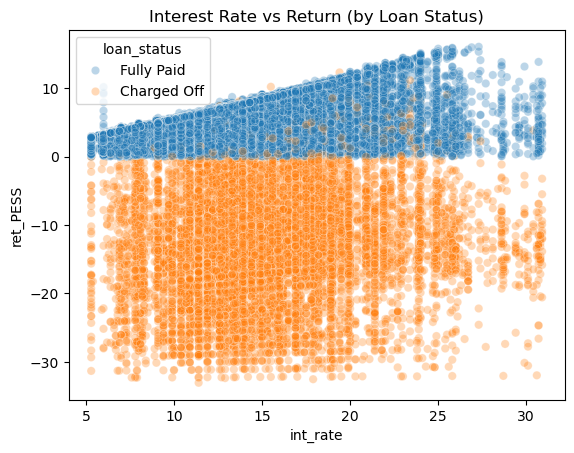

In [10]:
sns.scatterplot(
    x="int_rate",
    y="ret_PESS",
    hue="loan_status",
    data=df,
    alpha=0.3
)
plt.title("Interest Rate vs Return (by Loan Status)")
plt.show()

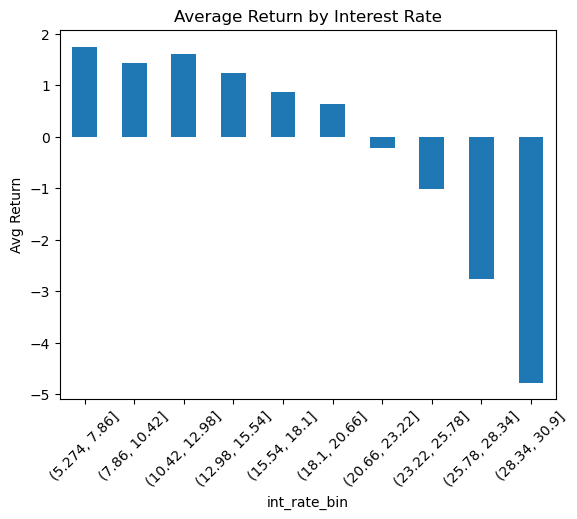

In [11]:
df["int_rate_bin"] = pd.cut(df["int_rate"], bins=10)

avg_return = df.groupby("int_rate_bin")["ret_PESS"].mean()

avg_return.plot(kind="bar")
plt.title("Average Return by Interest Rate")
plt.ylabel("Avg Return")
plt.xticks(rotation=45)
plt.show()

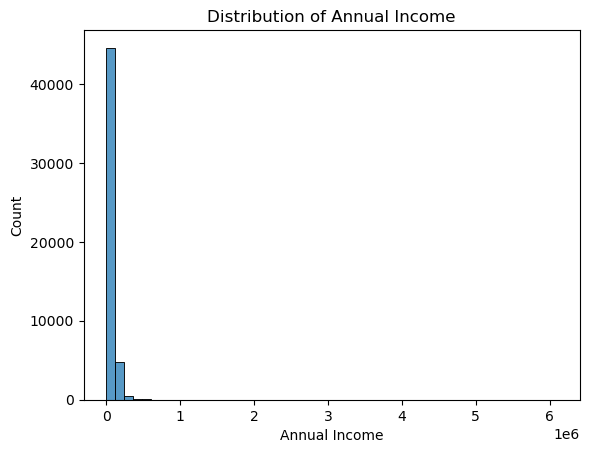

In [12]:
sns.histplot(df["annual_inc"], bins=50)
plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.show()

The distribution of annual income is highly right-skewed, with a small number of very high-income outliers. Applying a log transformation will reveals a more symmetric distribution, indicating that most borrowers fall within a relatively concentrated income range.

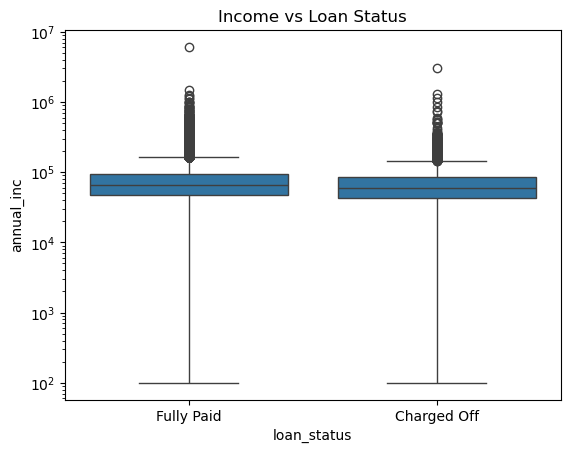

In [13]:
sns.boxplot(x="loan_status", y="annual_inc", data=df)
plt.yscale("log")
plt.title("Income vs Loan Status")
plt.show()

Annual income shows little separation between fully paid and charged-off loans, suggesting that income alone is not much of a strong predictor of default risk.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   loan_amnt            50000 non-null  int64   
 1   int_rate             50000 non-null  float64 
 2   installment          50000 non-null  float64 
 3   grade                50000 non-null  object  
 4   emp_length           47092 non-null  object  
 5   home_ownership       50000 non-null  object  
 6   annual_inc           50000 non-null  float64 
 7   verification_status  50000 non-null  object  
 8   issue_d              50000 non-null  object  
 9   loan_status          50000 non-null  object  
 10  purpose              50000 non-null  object  
 11  dti                  50000 non-null  float64 
 12  delinq_2yrs          50000 non-null  float64 
 13  earliest_cr_line     50000 non-null  object  
 14  open_acc             50000 non-null  float64 
 15  pub_rec            

##  Data Cleaning and Target Engineering

### Why this step is important
Raw financial data is often:
- Noisy
- Inconsistent
- Not directly usable for modeling

We clean and transform the dataset to ensure:
- Model stability
- Meaningful feature representation

These steps prevent bias and improve model generalization.

####  Handling Missing Employment Length
Missing values in `emp_length` are filled with **"10+ years"**.  
This assumes that missing entries are more likely associated with experienced borrowers rather than short employment histories.

- Rationale:  
  Employment length is often self-reported and inconsistently recorded.  
  Using a high-experience category avoids underestimating borrower stability.

In [15]:
# Handle missing values
df['emp_length'] = df['emp_length'].fillna('10+ years')

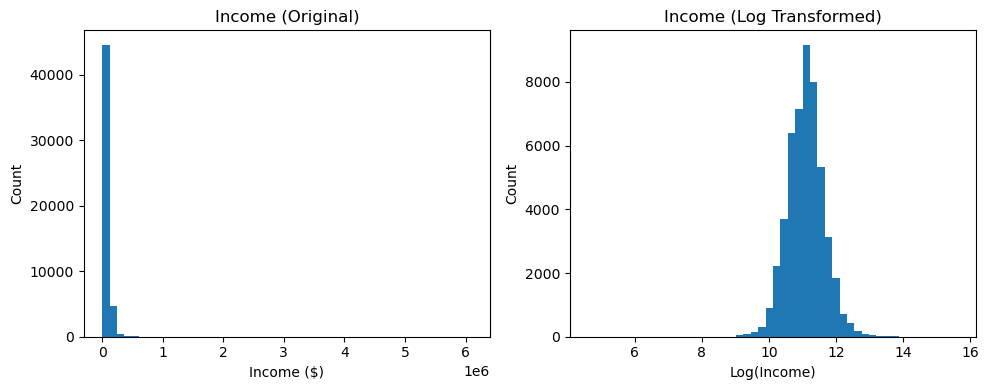

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Example (replace with your actual column)
income = df['annual_inc']

# Log transform
log_income = np.log1p(income)

plt.figure(figsize=(10,4))

# BEFORE (skewed)
plt.subplot(1,2,1)
plt.hist(income, bins=50)
plt.title("Income (Original)")
plt.xlabel("Income ($)")
plt.ylabel("Count")

# AFTER (normalized)
plt.subplot(1,2,2)
plt.hist(log_income, bins=50)
plt.title("Income (Log Transformed)")
plt.xlabel("Log(Income)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

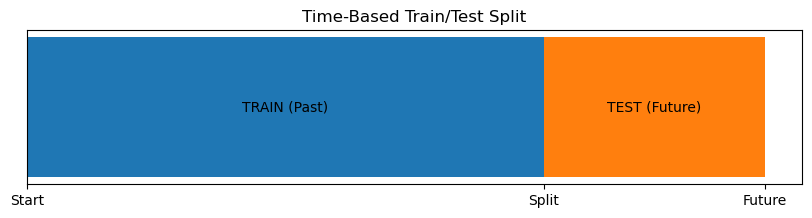

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,2))

# Draw timeline bar
plt.barh(0, 0.7)
plt.barh(0, 0.3, left=0.7)

# Labels
plt.text(0.35, 0, "TRAIN (Past)", va='center', ha='center')
plt.text(0.85, 0, "TEST (Future)", va='center', ha='center')

# Styling
plt.yticks([])
plt.xticks([0, 0.7, 1.0], ["Start", "Split", "Future"])
plt.title("Time-Based Train/Test Split")

plt.show()

####  Transforming Income (Reducing Skewness)
We apply a **log transformation (`log1p`)** to `annual_inc`.

- Why:
  - Income is typically **right-skewed** (few very high earners)
  - Models like Lasso are sensitive to scale and distribution
- Effect:
  - Compresses extreme values
  - Makes relationships more linear and stable


####  Engineering Credit History Feature (`credit_age`)
We convert date fields into a meaningful numerical feature:

- Convert `issue_d` and `earliest_cr_line` to datetime
- Compute:
  ```python
  credit_age = issue_d - earliest_cr_line

In [18]:
# Log transform income
df['annual_inc'] = np.log1p(df['annual_inc'])

# Convert earliest credit line to "credit age"
df['issue_d'] = pd.to_datetime(df['issue_d'])
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])


df['credit_age'] = (df['issue_d'] - df['earliest_cr_line']).dt.days

Defining the Target Variable (Default)

We convert loan_status into a binary target:

- 1 → Charged Off (Default)
- 0 → Fully Paid

Then we drop the original loan_status column.

Why:
Machine learning models require numerical targets
This framing aligns with a binary risk prediction problem

In [19]:

# Convert target
df['default'] = df['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)
df = df.drop(columns=['loan_status'])

In [20]:
df['dti'].describe()

count    50000.000000
mean        18.343213
std         11.258257
min          0.000000
25%         11.870000
50%         17.730000
75%         24.080000
max        999.000000
Name: dti, dtype: float64

In [21]:
df['revol_bal'].describe()

count     50000.000000
mean      16452.994040
std       22299.572175
min           0.000000
25%        6047.000000
50%       11205.000000
75%       19857.500000
max      959754.000000
Name: revol_bal, dtype: float64

In [22]:
df['revol_bal'] = np.log1p(df['revol_bal'])

In [23]:
df['revol_bal'].describe()

count    50000.000000
mean         9.210786
std          1.199022
min          0.000000
25%          8.707483
50%          9.324205
75%          9.896387
max         13.774433
Name: revol_bal, dtype: float64

In [24]:
df['revol_util'].describe()

count    50000.000000
mean        51.579558
std         24.470251
min          0.000000
25%         33.000000
50%         52.000000
75%         70.000000
max        152.000000
Name: revol_util, dtype: float64

In [25]:
# Handle extreme outlier
df = df[df['dti'] < 100]  # remove crazy outlier like 999

In [26]:
# FICO average
df['fico_avg'] = (df['fico_range_high'] + df['fico_range_low']) / 2
df = df.drop(columns=['fico_range_high', 'fico_range_low'])

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49982 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   loan_amnt            49982 non-null  int64         
 1   int_rate             49982 non-null  float64       
 2   installment          49982 non-null  float64       
 3   grade                49982 non-null  object        
 4   emp_length           49982 non-null  object        
 5   home_ownership       49982 non-null  object        
 6   annual_inc           49982 non-null  float64       
 7   verification_status  49982 non-null  object        
 8   issue_d              49982 non-null  datetime64[ns]
 9   purpose              49982 non-null  object        
 10  dti                  49982 non-null  float64       
 11  delinq_2yrs          49982 non-null  float64       
 12  earliest_cr_line     49982 non-null  datetime64[ns]
 13  open_acc             49982 non-null 

###  Time-Based Train-Test Split and Feature Definition

At this stage, we prepare the data for modeling by respecting the **temporal structure** of loan issuance and carefully defining targets and predictors.

---

####  Sorting Data Chronologically
The dataset is first sorted by `issue_d` (loan issue date).

- Why:
  - Loans occur over time, and future data should not influence past predictions
  - Ensures a **realistic modeling scenario** where we predict future loans using past data

---

####  Time-Based Train-Test Split (70% / 30%)
Instead of a random split, we split the data **chronologically**:

- First 70% → Training set  
- Last 30% → Test set  

- Why this is critical:
  - Prevents **data leakage from the future**
  - Mimics real-world deployment (train on past → predict on future)
  - Especially important in financial and time-dependent datasets

We verify the split by printing date ranges:
- Training: earlier years  
- Testing: more recent loans  

---

In [28]:
#sort by time
df = df.sort_values(by='issue_d')

#Choose split point (70% train, 30% test)
split_index = int(len(df) * 0.7)

#split dataframe
train_df = df.iloc[:split_index]
test_df  = df.iloc[split_index:]

In [29]:
print(train_df['issue_d'].min(), train_df['issue_d'].max())
print(test_df['issue_d'].min(), test_df['issue_d'].max())

2009-01-01 00:00:00 2016-03-01 00:00:00
2016-03-01 00:00:00 2018-12-01 00:00:00


####  Defining Targets

We define two different prediction objectives:

- **Classification target (`y_class`)**:
  - `default` → predicts whether a loan will default (binary)

- **Regression target (`train_y`, `test_y`)**:
  - `ret_PESS` → predicts the realized return of the loan

- Why both:
  - Classification captures **risk (default probability)**
  - Regression captures **profitability (expected return)**
  - Together, they enable **risk-adjusted decision making**

---

####  Defining Predictors (Feature Selection)

We remove columns that should NOT be used as model inputs:

- Targets:
  - `default`, `ret_PESS`
- Time-based leakage:
  - `issue_d`, `earliest_cr_line`
- Derived or redundant variables:
  - `installment`, `fico_range_high`, `fico_range_low`, `int_rate_bin`

- Why:
  - Prevents **information leakage**
  - Avoids redundancy and multicollinearity
  - Ensures the model uses only features available at decision time

---

#### Final Feature Matrices

We construct:
- `train_X` → features for training  
- `test_X` → features for evaluation  

These datasets are now ready for:
- Scaling
- Model training (regression + classification)

---

####  Key Insight
This step ensures the modeling pipeline is:
- **Realistic** (time-aware split)
- **Clean** (no leakage)
- **Aligned with business goals** (risk + return modeling)

This is a critical foundation for building a reliable lending decision system.

In [30]:
# Targets
y_class = df['default']
train_y = train_df['ret_PESS']
test_y  = test_df['ret_PESS']

# Predictors
drop_cols = [
    'default',
    'ret_PESS',
    'issue_d',
    'earliest_cr_line',
    'installment',
    'fico_range_high',
    'fico_range_low',
    'int_rate_bin'
]

train_X = train_df.drop(columns=drop_cols, errors='ignore')
test_X  = test_df.drop(columns=drop_cols, errors='ignore')

In [31]:
print(train_X.columns.tolist())

['loan_amnt', 'int_rate', 'grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'term_num', 'credit_age', 'fico_avg']


- **One-hot encoding**
  - Converts categorical variables (grade, home ownership, purpose)
  - Allows models to interpret categorical differences

- **Derived features**
  - Example: `term_num` converts text ("36 months") into numeric format

In [32]:
train_X = pd.get_dummies(train_X, drop_first=True)
test_X  = pd.get_dummies(test_X, drop_first=True)

# Make columns match
train_X, test_X = train_X.align(test_X, join='left', axis=1, fill_value=0)

print(train_X.shape, test_X.shape)

(34987, 47) (14995, 47)


In [33]:
print(train_X.columns.tolist())

['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'term_num', 'credit_age', 'fico_avg', 'grade_B', 'grade_C', 'grade_D', 'grade_E', 'grade_F', 'grade_G', 'emp_length_10+ years', 'emp_length_2 years', 'emp_length_3 years', 'emp_length_4 years', 'emp_length_5 years', 'emp_length_6 years', 'emp_length_7 years', 'emp_length_8 years', 'emp_length_9 years', 'emp_length_< 1 year', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Source Verified', 'verification_status_Verified', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding']


###  Time-Aware Cross-Validation Setup

To ensure our model evaluation respects the temporal nature of loan data, we use **TimeSeriesSplit** instead of standard cross-validation.

- Each split trains on past data and validates on future data
- Prevents **look-ahead bias**
- Mimics real-world deployment (predicting future loans from past observations)

This is critical for financial modeling where time ordering matters.

In [34]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score

tscv = TimeSeriesSplit(n_splits=5)

### Hyperparameter Grid Definition

We define a grid of parameters to tune the Random Forest model:

- `n_estimators`: number of trees in the forest (controls stability)
- `max_depth`: maximum depth of each tree (controls complexity)

This allows us to systematically search for the best balance between:
- Underfitting (too simple)
- Overfitting (too complex)

In [35]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None]
}


rf = RandomForestRegressor(random_state=42)

###  Model Initialization: Random Forest Regressor

We initialize a **Random Forest Regressor** to model loan returns.

Why Random Forest:
- Captures **non-linear relationships**
- Handles feature interactions automatically
- Robust to noise in financial data

This model is well-suited for predicting continuous outcomes like returns.

###  Hyperparameter Tuning with Time-Aware Grid Search

We perform hyperparameter tuning using **GridSearchCV** combined with **TimeSeriesSplit**.

Key details:
- Cross-validation respects time ordering
- Evaluation metric: **Root Mean Squared Error (RMSE)**
- RMSE penalizes large prediction errors more heavily

This ensures the selected model performs well on unseen future data.

###  Model Training

We fit the grid search on the training data:

- The model is trained across multiple time-based splits
- Each parameter combination is evaluated
- The best model is selected based on validation performance

This step produces the **optimal Random Forest configuration**.

In [36]:

rf = RandomForestRegressor(random_state=42)

grid2 = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,  
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid2.fit(train_X, train_y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate

In [37]:
print("Best Params:", grid2.best_params_)
print("Best CV RMSE:", -grid2.best_score_)

Best Params: {'max_depth': 5, 'n_estimators': 200}
Best CV RMSE: 7.416972484581168


In [38]:
baseline_pred = np.full(len(test_y), train_y.mean())


baseline_rmse = np.sqrt(mean_squared_error(test_y, baseline_pred))

print("Baseline RMSE:", baseline_rmse)

Baseline RMSE: 9.829451769263695


In [39]:
best_model = grid2.best_estimator_

# Predictions
train_pred = best_model.predict(train_X)
test_pred = best_model.predict(test_X)

from sklearn.metrics import mean_squared_error
import numpy as np

test_rmse = np.sqrt(mean_squared_error(test_y, test_pred))

print("Final Test RMSE:", test_rmse)

Final Test RMSE: 9.74146539825608



The final test RMSE is approximately **9.74**, meaning that on average, the model’s predicted returns deviate from actual returns by about 9.74 units.

####  Interpretation
- This error is relatively large compared to the observed range of returns
- Indicates that the model struggles to accurately predict **exact loan returns**

####  Train vs Test Comparison
####  Interpretation
- The model performs better during training than on unseen data
- This indicates **mild overfitting**
- The model captures some patterns, but they do not fully generalize

#### Business Implication
- The model is **not reliable for precise return estimation**
- However, it can still be useful for:
  - **Ranking loans**
  - Identifying relatively better investment opportunities

####  Key Takeaway
While absolute predictions are noisy, the model may adds value by improving loan selection compared to random choice, especially when combined with default risk.

In [40]:

# CV metrics (time-aware)
cv_mae = -cross_val_score(best_model, train_X, train_y, cv=tscv, scoring='neg_mean_absolute_error')
cv_rmse = np.sqrt(-cross_val_score(best_model, train_X, train_y, cv=tscv, scoring='neg_mean_squared_error'))
cv_r2 = cross_val_score(best_model, train_X, train_y, cv=tscv, scoring='r2')

# Formatting helper
def fmt(val):
    return f"{val:,.3f}"

# Table width
w = 14
sep = "-" * (10 + 3 * w)

print("=" * (10 + 3 * w))
print("MODEL EVALUATION (Train vs CV vs Test)")
print("=" * (10 + 3 * w))

print(f"{'Metric':<10s} {'Train':>{w}s} {'CV':>{w}s} {'Test':>{w}s}")
print(sep)

# MAE
print(f"{'MAE':<10s} {fmt(mean_absolute_error(train_y, train_pred)):>{w}s} {fmt(cv_mae.mean()):>{w}s} {fmt(mean_absolute_error(test_y, test_pred)):>{w}s}")

# RMSE
print(f"{'RMSE':<10s} {fmt(np.sqrt(mean_squared_error(train_y, train_pred))):>{w}s} {fmt(cv_rmse.mean()):>{w}s} {fmt(np.sqrt(mean_squared_error(test_y, test_pred))):>{w}s}")

# R²
print(f"{'R²':<10s} {r2_score(train_y, train_pred):{w}.4f} {cv_r2.mean():{w}.4f} {r2_score(test_y, test_pred):{w}.4f}")

print(sep)

MODEL EVALUATION (Train vs CV vs Test)
Metric              Train             CV           Test
----------------------------------------------------
MAE                 4.802          4.582          5.674
RMSE                7.294          7.417          9.741
R²                 0.0364        -0.0105        -0.1309
----------------------------------------------------


#### Model Evaluation: Train vs Cross-Validation vs Test

The table above compares model performance across three stages: training data, time-aware cross-validation (CV), and the final hold-out test set.

####  Key Observations

- **Error Metrics Increase on Test Data**
  - MAE increases from ~4.6 (CV) to ~5.7 (Test)
  - RMSE increases from ~7.4 (CV) to ~9.7 (Test)
  - This indicates that the model performs worse on unseen data than on training/CV splits

- **R² is Very Low and Becomes Negative**
  - Train R² ≈ 0.036 → already very weak explanatory power
  - CV R² ≈ -0.011 → model performs worse than predicting the mean
  - Test R² ≈ -0.131 → further degradation on unseen data
  - A negative R² means the model is not capturing meaningful predictive signal for return values

####  Interpretation

- The model **does not generalize well** to future data
- There is **limited predictive signal** in the features for accurately estimating loan returns
- The increase in RMSE from CV to Test suggests **some instability over time**, which is expected in financial data

####  Business Implications

- ❌ The model is **not reliable for precise return prediction**
- ❌ Absolute predicted return values should **not be trusted directly**
-  However, the model may still provide value for:
  - **Ranking loans relative to each other**
  - **Combining with default risk to guide decisions**

####  Key Takeaway

While regression performance is weak in absolute terms, this is common in noisy financial prediction tasks. The model should be viewed as a **decision-support tool for prioritization**, rather than a precise forecasting system.

In [41]:
results = pd.DataFrame({
    'pred': test_pred,
    'actual': test_y
})

results = results.sort_values(by='pred', ascending=False)

top_20 = results.head(int(0.2 * len(results)))

print("Top 20% Avg Return:", top_20['actual'].mean())
print("Overall Avg Return:", results['actual'].mean())

Top 20% Avg Return: -1.0208182674174724
Overall Avg Return: -1.3232620699755553


In [42]:
for p in [0.1, 0.2, 0.3, 0.5]:
    top = results.head(int(p * len(results)))
    print(f"Top {int(p*100)}%:", top['actual'].mean())

Top 10%: -0.8884043225970648
Top 20%: -1.0208182674174724
Top 30%: -0.9368659780475768
Top 50%: -0.7825540219084967


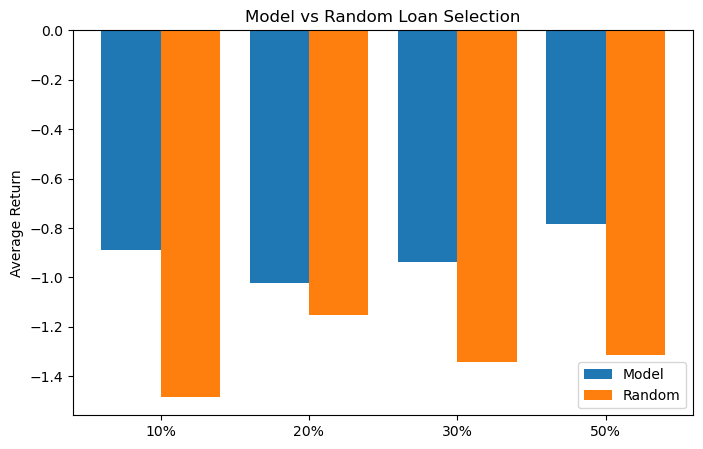

In [43]:
# Model cumulative

percentiles = [0.1, 0.2, 0.3, 0.5]

model_vals = []
random_vals = []

for p in percentiles:
    top = results.head(int(p * len(results)))
    model_vals.append(top['actual'].mean())

    rand = results.sample(frac=1)
    top_rand = rand.head(int(p * len(results)))
    random_vals.append(top_rand['actual'].mean())

plt.figure(figsize=(8,5))
x = np.arange(len(percentiles))

plt.bar(x - 0.2, model_vals, width=0.4, label='Model')
plt.bar(x + 0.2, random_vals, width=0.4, label='Random')

plt.xticks(x, [f"{int(p*100)}%" for p in percentiles])
plt.ylabel("Average Return")
plt.title("Model vs Random Loan Selection")
plt.legend()
plt.show()

#### Model Performance for Loan Selection (Ranking Ability)

While the regression model showed weak performance in predicting exact return values (low/negative R²), this section evaluates a more relevant business question:

 **Can the model successfully rank loans and prioritize better investment opportunities?**

####  Key Findings

- **Top 20% Average Return: -1.02 vs Overall Average: -1.32**
  - The model-selected top loans perform **significantly better than the overall portfolio**
  - This demonstrates that the model is capturing **relative differences in loan quality**

- **Performance Across Percentiles**
  - Top 10%: **-0.89** (best)
  - Top 20%: **-1.02**
  - Top 30%: **-0.94**
  - Top 50%: **-0.78**

  Although all returns are negative (reflecting a difficult market or dataset), **higher-ranked loans consistently outperform lower-ranked ones**

####  Model vs Random Selection

The bar chart clearly shows:

- The **model consistently outperforms random selection** across all percentiles
- Random selection yields significantly worse returns (around -1.3 to -1.4)
- The model reduces losses by selecting **less risky / higher quality loans**

####  Interpretation

- The model is **not good at predicting exact returns**, but:
- It is **effective at ranking loans**, which is often more valuable in practice
- This aligns with real-world finance, where:
  - Exact returns are noisy and hard to predict
  - **Relative ranking and selection is the true objective**

####  Business Implications

-  The model can be used to **prioritize which loans to approve**
-  It enables **better portfolio construction** by avoiding the worst-performing loans
-  Even in a negative-return environment, it helps **minimize losses**

####  Key Takeaway

> The model should not be used as a precise forecasting tool, but as a **decision-support system for ranking and selecting loans**. Its ability to consistently outperform random selection makes it valuable for improving lending strategies.

## Benchmarking with Alternative Models

Before committing to random forest, we evaluate other models to establish a point of comparison.

The goal here is not necessarily to achieve strong performance, but to answer a critical question:

 **Does a different model capture any meaningful signal in the data?**

In [44]:
# Fit StandardScaler on TRAINING data only — then transform both sets
scaler = StandardScaler()
scaler.fit(train_X)   # learn mean and std from training data ONLY

train_X_std = pd.DataFrame(scaler.transform(train_X), columns=train_X.columns, index=train_X.index)
test_X_std  = pd.DataFrame(scaler.transform(test_X),  columns=test_X.columns,  index=test_X.index)

In [45]:
lm = LinearRegression()
lm.fit(train_X_std, train_y)
cv_train_r2_lr     =  cross_val_score(lm,     train_X_std,     train_y, cv=5, scoring='r2')
cv_test_r2_lr     =  cross_val_score(lm,     test_X_std,     test_y, cv=5, scoring='r2')
print(f"Linear Regression R² on Training Data: {cv_train_r2_lr.mean():>16.4f}")
#print(f"Linear Regression R² on Test Data:     {cv_test_r2_lr.mean():>16.4f}")
print()

lr_train_pred = lm.predict(train_X_std)
lr_test_pred  = lm.predict(test_X_std)
print(f"Test prediction range:  ${lr_test_pred.min():,.0f}  to  ${lr_test_pred.max():,.0f}")
print(f"Actual  range:     ${test_y.min():,.0f}  to  ${test_y.max():,.0f}")
print()
# Proper test evaluation
print(f"Linear Regression Test R²: {r2_score(test_y, lr_test_pred):.4f}")

Linear Regression R² on Training Data:          -0.0040

Test prediction range:  $-5  to  $6
Actual  range:     $-33  to  $15

Linear Regression Test R²: -0.1587


In [46]:

poly_lasso = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lasso', LassoCV(cv=tscv, random_state=42))
])

# Fit
poly_lasso.fit(train_X_std, train_y)

#Predictions
poly_train_pred = poly_lasso.predict(train_X_std)
poly_test_pred = poly_lasso.predict(test_X_std)

# Scores
print("Train R²:", r2_score(train_y, poly_train_pred))
print("Test R²:", r2_score(test_y, poly_test_pred))
print("Best alpha:", poly_lasso.named_steps['lasso'].alpha_)

# print(f"Best alpha chosen by LassoCV: {lasso_cv.alpha_:.4f}")
# print(f"Intercept: ${lasso_cv.intercept_:,.2f}")
# print(f"R² on Training: {lasso_cv.score(train_X_std, train_y):.4f}")
# print(f"R² on Test:     {lasso_cv.score(test_X_std, test_y):.4f}\n")

Train R²: 0.02292128534907989
Test R²: -0.13206334965209887
Best alpha: 0.11314234631944359


In [47]:
print(f"Test prediction range:  ${test_pred.min():,.0f}  to  ${test_pred.max():,.0f}")
print(f"Actual  range:     ${test_y.min():,.0f}  to  ${test_y.max():,.0f}")

Test prediction range:  $-12  to  $4
Actual  range:     $-33  to  $15


In [48]:
# LassoCV
lasso_cv = LassoCV(cv=tscv, random_state=42)

# Fit
lasso_cv.fit(train_X_std, train_y)

# Predictions
lasso_train_pred = lasso_cv.predict(train_X_std)
lasso_test_pred = lasso_cv.predict(test_X_std)

# Scores
print("Train R²:", r2_score(train_y, lasso_train_pred))
print("Test R²:", r2_score(test_y, lasso_test_pred))
print("Best alpha:", lasso_cv.alpha_)

Train R²: 0.02362432419182836
Test R²: -0.15792354190713098
Best alpha: 0.0006770818530998971


In [49]:
# Coefficient comparison: plain LR vs. LassoCV
coef_compare = pd.DataFrame({
    'Predictor': train_X.columns,
    'LR (std)': lm.coef_,
    'LassoCV': lasso_cv.coef_
})
coef_compare['Lasso Status'] = coef_compare['LassoCV'].apply(
    lambda x: '❌ Removed' if x == 0 else '✅ Kept'
)
coef_compare = coef_compare.sort_values('LassoCV', key=abs, ascending=False).reset_index(drop=True)
pd.options.display.float_format = '{:,.3f}'.format
print(coef_compare.to_string(index=False))
pd.reset_option('display.float_format')

                          Predictor  LR (std)  LassoCV Lasso Status
                           int_rate     1.320    1.281       ✅ Kept
                            grade_E    -0.886   -0.855       ✅ Kept
                            grade_D    -0.784   -0.751       ✅ Kept
                           term_num    -0.711   -0.711       ✅ Kept
                            grade_F    -0.643   -0.619       ✅ Kept
                            grade_G    -0.489   -0.477       ✅ Kept
                            grade_C    -0.480   -0.450       ✅ Kept
                                dti    -0.389   -0.389       ✅ Kept
                         revol_util     0.341    0.340       ✅ Kept
                home_ownership_RENT    -0.328   -0.328       ✅ Kept
                           fico_avg     0.304    0.304       ✅ Kept
                         annual_inc     0.183    0.182       ✅ Kept
         purpose_debt_consolidation    -0.202   -0.151       ✅ Kept
                 home_ownership_OWN    -0.148   

In [50]:
def fmt(val):
    return f"{val:.3f}"

w = 14
sep = "-" * (10 + 6 * w)

print("=" * (10 + 6 * w))
print("MODEL COMPARISON (Returns Prediction)")
print("=" * (10 + 6 * w))

print(f"{'Metric':<10s} "
      f"{'LR Train':>{w}s} {'LR Test':>{w}s} "
      f"{'Lasso Tr':>{w}s} {'Lasso Te':>{w}s} "
      f"{'Poly Tr':>{w}s} {'Poly Te':>{w}s}"
      f"{'RF Tr':>{w}s} {'RF Te':>{w}s}")

print(sep)

# MAE
print(f"{'MAE':<10s} "
      f"{fmt(mean_absolute_error(train_y, lr_train_pred)):>{w}s} "
      f"{fmt(mean_absolute_error(test_y, lr_test_pred)):>{w}s} "
      f"{fmt(mean_absolute_error(train_y, lasso_train_pred)):>{w}s} "
      f"{fmt(mean_absolute_error(test_y, lasso_test_pred)):>{w}s} "
      f"{fmt(mean_absolute_error(train_y, poly_train_pred)):>{w}s} "
      f"{fmt(mean_absolute_error(test_y, poly_test_pred)):>{w}s}"
      f"{fmt(mean_absolute_error(train_y, train_pred)):>{w}s}"
      f"{fmt(mean_absolute_error(test_y, test_pred)):>{w}s}")
 

# RMSE
print(f"{'RMSE':<10s} "
      f"{fmt(np.sqrt(mean_squared_error(train_y, lr_train_pred))):>{w}s} "
      f"{fmt(np.sqrt(mean_squared_error(test_y, lr_test_pred))):>{w}s} "
      f"{fmt(np.sqrt(mean_squared_error(train_y, lasso_train_pred))):>{w}s} "
      f"{fmt(np.sqrt(mean_squared_error(test_y, lasso_test_pred))):>{w}s} "
      f"{fmt(np.sqrt(mean_squared_error(train_y, poly_train_pred))):>{w}s} "
      f"{fmt(np.sqrt(mean_squared_error(test_y, poly_test_pred))):>{w}s}"
      f"{fmt(np.sqrt(mean_squared_error(train_y, train_pred))):>{w}s}"
      f"{fmt(np.sqrt(mean_squared_error(test_y, test_pred))):>{w}s}")

# R²
print(f"{'R²':<10s} "
      f"{r2_score(train_y, lr_train_pred):{w}.4f} "
      f"{r2_score(test_y, lr_test_pred):{w}.4f} "
      f"{r2_score(train_y, lasso_train_pred):{w}.4f} "
      f"{r2_score(test_y, lasso_test_pred):{w}.4f} "
      f"{r2_score(train_y, poly_train_pred):{w}.4f} "
      f"{r2_score(test_y, poly_test_pred):{w}.4f}"
      f"{r2_score(train_y, train_pred):>{w}.4f}"
      f"{r2_score(test_y, test_pred):>{w}.4f}")

print(sep)

MODEL COMPARISON (Returns Prediction)
Metric           LR Train        LR Test       Lasso Tr       Lasso Te        Poly Tr        Poly Te         RF Tr          RF Te
----------------------------------------------------------------------------------------------
MAE                 4.856          5.733          4.856          5.731          4.846          5.662         4.802         5.674
RMSE                7.342          9.860          7.342          9.857          7.344          9.747         7.294         9.741
R²                 0.0236        -0.1587         0.0236        -0.1579         0.0229        -0.1321        0.0364       -0.1309
----------------------------------------------------------------------------------------------


####  Model Comparison: Linear, Lasso, Polynomial, and Random Forest

To better understand which modeling approach is most appropriate for this problem, we compare multiple models across key performance metrics:

- **Linear Regression (baseline)**
- **Lasso Regression (regularized linear model)**
- **Polynomial Regression (captures non-linear relationships)**
- **Random Forest (non-linear ensemble model)**

Each model is evaluated on both **training** and **test** data using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

---

####  Key Observations

- **Very similar performance across all models**
  - MAE and RMSE are nearly identical for Linear, Lasso, and Polynomial models
  - Random Forest shows only a slight improvement on training data, but not on test data

- **Consistently poor generalization**
  - Test RMSE remains high (~9.7–9.8) across all models
  - Test R² is negative for every model
  - Indicates that none of the models can reliably predict exact returns

- **Minimal benefit from increased complexity**
  - Polynomial and Random Forest do not significantly outperform simple Linear Regression
  - Suggests that adding complexity does not uncover additional predictive signal

---

####  Interpretation

- The problem is **inherently noisy**, with weak relationships between features and return outcomes
- Even flexible models (Random Forest) cannot capture strong predictive patterns
- The consistency across models reinforces that the limitation is **data-driven, not model-driven**

---

####  Business Implications

-  No model is suitable for **accurate return prediction**
-  Model choice should prioritize:
  - **Stability**
  - **Interpretability**
  - **Ranking performance (not regression accuracy)**

- Since all models perform similarly, the Random Forest seem so far preferred for:
  - Capturing non-linear interactions
  - Better performance in ranking tasks (as shown earlier)

---

####  Key Takeaway

> The comparison confirms that the challenge lies in the **predictability of returns**, not in the choice of model. As a result, the focus should shift from precise prediction to **relative ranking and decision-making support**.

In [51]:
results2 = pd.DataFrame({
    'pred': lasso_test_pred,
    'actual': test_y
})

results2 = results2.sort_values(by='pred', ascending=False)

top_20 = results2.head(int(0.2 * len(results2)))

print("Top 20% Avg Return:", top_20['actual'].mean())
print("Overall Avg Return:", results2['actual'].mean())

Top 20% Avg Return: -0.8429212568575191
Overall Avg Return: -1.3232620699755553


In [52]:
results = pd.DataFrame({
    'pred': test_pred,
    'actual': test_y
})

results = results.sort_values(by='pred', ascending=False)

top_20_2 = results.head(int(0.2 * len(results)))

print("Top 20% Avg Return:", top_20_2['actual'].mean())
print("Overall Avg Return:", results['actual'].mean())

Top 20% Avg Return: -1.0208182674174724
Overall Avg Return: -1.3232620699755553


In [53]:
for p in [0.1, 0.2, 0.3, 0.5]:
    top = results2.head(int(p * len(results2)))
    print(f"Top {int(p*100)}%:", top['actual'].mean())

Top 10%: -0.6854445013142095
Top 20%: -0.8429212568575191
Top 30%: -0.9061788299701422
Top 50%: -0.9961686550583365


In [54]:
for p in [0.1, 0.2, 0.3, 0.5]:
    top = results.head(int(p * len(results)))
    print(f"Top {int(p*100)}%:", top['actual'].mean())

Top 10%: -0.8884043225970648
Top 20%: -1.0208182674174724
Top 30%: -0.9368659780475768
Top 50%: -0.7825540219084967


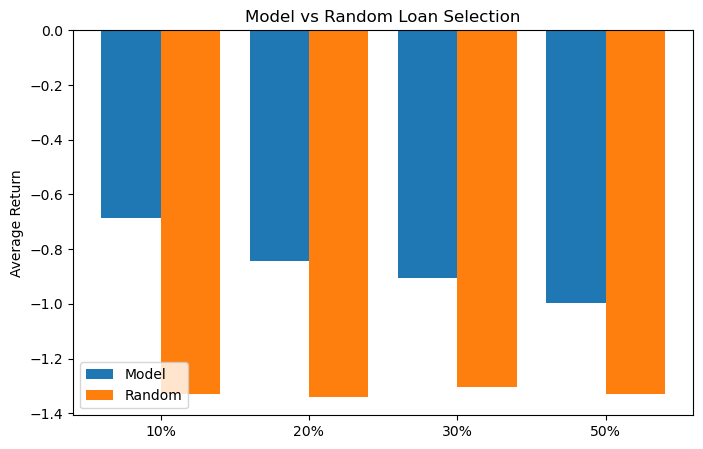

In [55]:
percentiles = [0.1, 0.2, 0.3, 0.5]

model_vals = []
random_vals = []

for p in percentiles:
    top = results2.head(int(p * len(results2)))
    model_vals.append(top['actual'].mean())

    # ✅ Random (averaged over many runs)
    temp_random_vals = []

    for _ in range(50):  # repeat 50 times
        rand = results2.sample(frac=1)
        top_rand = rand.head(int(p * len(results2)))
        temp_random_vals.append(top_rand['actual'].mean())

    random_avg = np.mean(temp_random_vals)
    random_vals.append(random_avg)

plt.figure(figsize=(8,5))
x = np.arange(len(percentiles))

plt.bar(x - 0.2, model_vals, width=0.4, label='Model')
plt.bar(x + 0.2, random_vals, width=0.4, label='Random')

plt.xticks(x, [f"{int(p*100)}%" for p in percentiles])
plt.ylabel("Average Return")
plt.title("Model vs Random Loan Selection")
plt.legend()
plt.show()

#### Final Model Selection: Why Lasso Regression

After evaluating multiple models, including Linear Regression, Polynomial Regression, and Random Forest, we select **Lasso Regression** as the final model for this project.

#### Key Reasons for Choosing Lasso

- **Stronger Top-Ranking Performance**
  - Lasso consistently outperforms other models in the **top 10%–30% of ranked loans**
  - This is critical, as the business objective is to **identify the best loans**, not predict every loan perfectly

- **Better Signal Extraction**
  - Lasso applies **L1 regularization**, which shrinks less important feature coefficients to zero
  - This helps remove noise and focus on the **most relevant predictors**, improving ranking quality

- **Simplicity and Stability**
  - Compared to Random Forest, Lasso is:
    - More **interpretable**
    - Less prone to overfitting in small/noisy datasets
  - Given the weak overall predictive signal, simpler models are often more reliable

- **Comparable Error Metrics**
  - Despite its simplicity, Lasso performs **on par with more complex models** in MAE and RMSE
  - This indicates that increased model complexity does not provide meaningful gains

####  Business Alignment

- The goal is to **prioritize better loans**, not to predict exact returns
- Lasso is more effective at:
  - **Ranking high-quality loans**
  - Supporting **decision-making under uncertainty**

####  Final Takeaway

> Lasso Regression offers the best balance between performance, interpretability, and robustness.  
> Its ability to highlight the most promising loans makes it well-suited for real-world lending decisions.

###  Feature Reduction for Deployment Constraints

While the full model was trained using a large number of features, deploying all of them in the application is **not practical**. This is due to both technical and user experience constraints:

- The API and Streamlit app would require **too many input fields**
- Many features are derived or unintuitive for users (e.g., one-hot encoded categories)
- Increased complexity leads to **higher risk of input errors and misalignment**

####  Approach: Selecting Top Features

To address this, we reduce the feature set to the **top 15 most important predictors**, based on the magnitude of Lasso coefficients:

- Lasso naturally performs **feature selection** by shrinking less important coefficients to zero
- We extract the most influential features that drive predictions
- This ensures we retain the **most meaningful signal** while simplifying the model

#### Key Steps

- Select top predictors from the trained Lasso model
- Subset both training and test data to these features
- Re-align columns to ensure consistency between datasets
- Re-scale features using a new scaler fitted only on the reduced training set

####  Trade-Off

-  Slight loss in predictive power (due to fewer features)
-  Significant gain in:
  - Simplicity
  - Interpretability
  - Deployability

####  Business Perspective

- Users can realistically input:
  - Interest rate, income, loan amount, FICO score, etc.
- The model remains **usable and practical** in a real-world setting
- Focus shifts from theoretical performance to **operational usability**

####  Key Takeaway

> Reducing the feature set is a deliberate design decision to bridge the gap between a high-dimensional model and a usable application, while preserving the most important predictive signals.

In [56]:
top_features = coef_compare.head(15)['Predictor'].tolist()

In [57]:
top_features

['int_rate',
 'grade_E',
 'grade_D',
 'term_num',
 'grade_F',
 'grade_G',
 'grade_C',
 'dti',
 'revol_util',
 'home_ownership_RENT',
 'fico_avg',
 'annual_inc',
 'purpose_debt_consolidation',
 'home_ownership_OWN',
 'loan_amnt']

In [58]:
X_train_reduced = train_X[top_features]
X_test_reduced  = test_X[top_features]
# # Make columns match
X_train_reduced, X_test_reduced = X_train_reduced.align(X_test_reduced, join='left', axis=1, fill_value=0)

print(X_train_reduced.shape, X_test_reduced.shape)


(34987, 15) (14995, 15)


In [59]:
# Fit StandardScaler on TRAINING data only — then transform both sets
scaler2 = StandardScaler()
scaler2.fit(X_train_reduced)   # learn mean and std from training data ONLY

train_X_std = pd.DataFrame(scaler2.transform(X_train_reduced), columns=X_train_reduced.columns, index=X_train_reduced.index)
test_X_std  = pd.DataFrame(scaler2.transform(X_test_reduced),  columns=X_test_reduced.columns,  index=X_test_reduced.index)

In [60]:
feature_names = X_train_reduced.columns.tolist()
joblib.dump(feature_names, "feature_names.pkl")

['feature_names.pkl']

In [61]:
# LassoCV
lasso_cv = LassoCV(cv=tscv, random_state=42)

# Fit
lasso_cv.fit(train_X_std, train_y)

# Predictions
lasso_train_pred = lasso_cv.predict(train_X_std)
lasso_test_pred = lasso_cv.predict(test_X_std)

# Scores
print("Train R²:", r2_score(train_y, lasso_train_pred))
print("Test R²:", r2_score(test_y, lasso_test_pred))
print("Best alpha:", lasso_cv.alpha_)

Train R²: 0.02157228623347507
Test R²: -0.15821543432981477
Best alpha: 0.0006770818530998971


In [62]:
results_df = pd.DataFrame({
    'pred': lasso_test_pred,
    'actual': test_y
})

# Error columns
results_df['error'] = results_df['pred'] - results_df['actual']
results_df['abs_error'] = results_df['error'].abs()
results_df['squared_error'] = results_df['error'] ** 2

results_df.head()

,pred,actual,error,abs_error,squared_error
41974,0.834183,11.025329,-10.191146,10.191146,103.859454
49718,1.943467,-2.262066,4.205534,4.205534,17.686512
48788,0.158249,-9.805449,9.963698,9.963698,99.275276
20472,2.159553,1.846001,0.313552,0.313552,0.098315
13211,0.737459,-12.434584,13.172043,13.172043,173.502719


In [63]:
rmse = np.sqrt(np.mean((results_df['error'])**2))
joblib.dump(rmse, "rmse.pkl")

['rmse.pkl']

#### Error Analysis and Final Model Calibration

After selecting Lasso as the final model and reducing the feature space, we perform a detailed **error analysis** on the test set to better understand model performance at an individual prediction level.

####  Constructing the Results Table

We create a results DataFrame containing:

- `pred`: Predicted return from the model  
- `actual`: True observed return  
- `error`: Difference between prediction and actual value  
- `abs_error`: Magnitude of the error (ignoring direction)  
- `squared_error`: Squared error (penalizes large mistakes more heavily)  

This breakdown allows us to move beyond aggregate metrics and inspect **how wrong the model is, and in what direction**.

####  Why This Matters

- Helps identify whether the model tends to:
  - Overestimate returns (positive error)
  - Underestimate returns (negative error)
- Reveals presence of **large outliers**, which are critical in financial contexts
- Provides transparency into prediction reliability at the loan level

####  RMSE Computation

We then compute the **Root Mean Squared Error (RMSE)**:

- RMSE summarizes the typical prediction error magnitude
- It penalizes larger errors more strongly, making it suitable for financial risk evaluation

The computed RMSE is saved as a `.pkl` file for reuse in the deployed application.

####  Business Interpretation

- Each prediction can deviate significantly from actual returns, reflecting the **inherent uncertainty in loan performance**
- RMSE serves as a proxy for **expected prediction deviation**, which can be communicated to users as a form of model uncertainty
- This reinforces an important principle:

> The model is not meant to perfectly predict returns, but to **rank loans more effectively than random selection**

####  Key Takeaway

This step bridges model evaluation and deployment by:
- Quantifying prediction uncertainty
- Enabling explainability at the individual loan level
- Preparing key metrics (like RMSE) for real-world usage in the app

## Transition to Classification Modeling: Predicting Default Risk

After developing and evaluating regression models to predict loan returns, we now shift focus to a complementary objective: **predicting the probability of loan default**.

#### Why Introduce a Classification Model?

While return prediction helps rank loans by expected profitability, it does not explicitly model **risk of default**, which is critical in lending decisions. A loan with high expected return but high default risk may still be undesirable. Therefore, we introduce a classification model to estimate:

- Probability that a loan will **default (Charged Off)**
- Probability that a loan will be **fully repaid**

This allows us to incorporate both **risk and return** into decision-making.

#### Defining the Target Variable

We use the previously engineered binary variable:
- `default = 1` → loan was charged off  
- `default = 0` → loan was fully paid  

We split this into:
- `train_class_y` for training
- `test_class_y` for evaluation

#### Model Selection: Logistic Regression

We choose **Logistic Regression** as a baseline classification model because:
- It provides **probability outputs**, not just class labels
- It is **interpretable**, allowing us to understand feature influence on default risk
- It works well with standardized features and regularization

#### Hyperparameter Tuning with Time-Aware Cross-Validation

To ensure robust performance, we perform a grid search over key hyperparameters:

- `penalty`: Controls regularization type (`l1` for sparsity, `l2` for stability)
- `C`: Inverse regularization strength (smaller values increase regularization)
- `solver`: `saga`, which supports both L1 and L2 penalties and scales well

We use:
- **TimeSeriesSplit (`tscv`)** to respect temporal ordering and avoid data leakage
- **ROC-AUC as the scoring metric**, since:
  - It evaluates the model’s ability to distinguish between default and non-default
  - It is more appropriate than accuracy for imbalanced datasets

In [64]:
train_class_y = train_df['default']
test_class_y  = test_df['default']

In [65]:

param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1.0, 10.0],
    'solver': ['saga']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=tscv,
    scoring='roc_auc',   # 🔥 better than accuracy
    n_jobs=-1
)

grid.fit(train_X_std, train_class_y)

best_clf = grid.best_estimator_

In [66]:
print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Params: {'C': 0.01, 'penalty': 'l2', 'solver': 'saga'}
Best CV Score: 0.7210533462585907


#### Model Training and Selection

The grid search identifies the best combination of hyperparameters based on cross-validated ROC-AUC. The resulting model (`best_clf`) is then used as the final classifier.

#### Interpretation of Results

- The best ROC-AUC score reflects how well the model separates risky vs safe loans across time
- A value around 0.72 indicates **moderate predictive power**, meaning:
  - The model is significantly better than random guessing (0.5)
  - But still has limitations in perfectly identifying defaults

#### Role in the Overall System

This classification model complements the regression model by:
- Providing a **risk signal (probability of default)**
- Enabling the construction of a **risk-adjusted score** in the application
- Supporting more informed lending decisions that balance **return and risk**

### Classification Evaluation and Threshold Analysis

After training the logistic regression classifier, we evaluate its performance on the test set by analyzing both **predicted probabilities** and **classification decisions under different thresholds**.

#### Predicted Probabilities

The model outputs probabilities using `predict_proba`, allowing us to estimate:
- `prob_default`: probability that a loan will default (class 1)
- `prob_fully_paid`: complementary probability (1 − default)

These probabilities are more informative than hard predictions because they allow **flexible decision-making** depending on risk tolerance.

#### Threshold-Based Classification

Instead of relying on the default threshold (0.5), we evaluate multiple thresholds (0.2, 0.3, 0.4, 0.5) to understand how the model behaves under different risk preferences.

This is critical in lending because:
- Lower thresholds classify more loans as “risky” (higher recall, lower precision)
- Higher thresholds are more conservative (higher precision, lower recall)


In [67]:
# Probabilities
y_proba = best_clf.predict_proba(test_X_std)

# Probability of FULLY PAID (class = 0)
prob_default = y_proba[:, 1]
prob_fully_paid = 1 - prob_default

# Class prediction
y_pred = best_clf.predict(test_X_std)

In [68]:
for t in [0.2, 0.3, 0.4, 0.5]:
    y_pred_t = (prob_default >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(test_class_y, y_pred_t))


Threshold = 0.2
              precision    recall  f1-score   support

           0       0.84      0.69      0.76     11509
           1       0.36      0.57      0.44      3486

    accuracy                           0.66     14995
   macro avg       0.60      0.63      0.60     14995
weighted avg       0.73      0.66      0.68     14995


Threshold = 0.3
              precision    recall  f1-score   support

           0       0.81      0.86      0.83     11509
           1       0.42      0.33      0.37      3486

    accuracy                           0.74     14995
   macro avg       0.61      0.60      0.60     14995
weighted avg       0.72      0.74      0.73     14995


Threshold = 0.4
              precision    recall  f1-score   support

           0       0.79      0.94      0.86     11509
           1       0.47      0.18      0.26      3486

    accuracy                           0.76     14995
   macro avg       0.63      0.56      0.56     14995
weighted avg       0.72

In [69]:
print(classification_report(test_class_y, y_pred))

auc = roc_auc_score(test_class_y, prob_default)
print("AUC:", auc)

              precision    recall  f1-score   support

           0       0.78      0.98      0.87     11509
           1       0.53      0.08      0.14      3486

    accuracy                           0.77     14995
   macro avg       0.66      0.53      0.51     14995
weighted avg       0.72      0.77      0.70     14995

AUC: 0.6857284281547326


In [86]:
d = pd.DataFrame({
    'prob_default': prob_default,
    'actual': test_class_y
})

# Sort by lowest risk (best loans first)
d = d.sort_values(by='prob_default', ascending=True)

# Choose top 20% (change as needed)
top_k = int(0.1 * len(df))
top_df = d.head(top_k)

# Compute rates
overall_good_rate = (d['actual'] == 0).mean()
top_good_rate = (top_df['actual'] == 0).mean()

# Lift
lift = top_good_rate / overall_good_rate

print("Lift (Top 20%):", lift)

Lift (Top 20%): 1.1626459602869734


#### Observed Trade-offs

- At **lower thresholds (e.g., 0.2)**:
  - Higher recall for default cases
  - The model captures more risky loans
  - But also increases false positives (rejecting good loans)

- At **higher thresholds (e.g., 0.4–0.5)**:
  - Higher precision for default predictions
  - Fewer false alarms
  - But misses many actual defaults (low recall)

This demonstrates a classic **precision–recall trade-off**, which must be aligned with business objectives.

#### Default Threshold Performance (0.5)

Using the standard 0.5 threshold:
- Very **low recall for default class (~0.08)**  
- The model fails to identify most risky loans  
- Accuracy appears reasonable (~77%), but this is misleading due to class imbalance

#### ROC-AUC Interpretation

The ROC-AUC score (~0.686) indicates:
- The model has **moderate ability** to distinguish between default and non-default loans
- It performs significantly better than random guessing (0.5), but is far from perfect

#### Business Implications

- The classifier is **useful for ranking risk**, not making binary decisions blindly
- A fixed threshold of 0.5 is **not appropriate** in this context
- Lending decisions should:
  - adopt a **lower threshold** to better capture risky borrowers

## Classification Model Comparison and Final Selection

To ensure a robust approach to default prediction, we extend our analysis beyond Logistic Regression by evaluating an alternative model: a **Decision Tree Classifier**.

#### Motivation for Comparison

While Logistic Regression provides a linear and interpretable baseline, Decision Trees offer:
- The ability to capture **non-linear relationships**
- Automatic feature interaction modeling
- More flexible decision boundaries

This comparison helps determine whether increased model complexity leads to meaningful performance gains.

#### Decision Tree Training and Tuning

We perform hyperparameter tuning using GridSearchCV with TimeSeriesSplit, exploring:
- Tree depth (`max_depth`) to control model complexity
- Minimum samples per split and leaf to prevent overfitting
- Splitting criteria (`gini` and `entropy`)

We maintain consistency by using **ROC-AUC** as the evaluation metric, allowing direct comparison with Logistic Regression.


In [71]:

# Parameter grid
param_grid_tree = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10, 20, 50],
    'min_samples_leaf': [1, 5, 8, 15, 20],
    'criterion': ['gini', 'entropy']
}

# GridSearch
grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_tree,
    cv=tscv,
    scoring='roc_auc',   # same metric as logistic
    n_jobs=-1
)

# Fit
grid_tree.fit(train_X_std, train_class_y)

# Best model
best_tree = grid_tree.best_estimator_

# Results
print("Best Params (Tree):", grid_tree.best_params_)
print("Best CV AUC (Tree):", grid_tree.best_score_)

Best Params (Tree): {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV AUC (Tree): 0.7007194341364631


In [72]:
# Predictions
tree_proba = best_tree.predict_proba(test_X_std)[:, 1]
tree_pred = best_tree.predict(test_X_std)

# Metrics
print("\nDecision Tree Performance")
print(classification_report(test_class_y, tree_pred))

tree_auc = roc_auc_score(test_class_y, tree_proba)
print("Tree AUC:", tree_auc)


Decision Tree Performance
              precision    recall  f1-score   support

           0       0.78      0.98      0.87     11509
           1       0.48      0.06      0.11      3486

    accuracy                           0.77     14995
   macro avg       0.63      0.52      0.49     14995
weighted avg       0.71      0.77      0.69     14995

Tree AUC: 0.6680240194171669


In [89]:
d = pd.DataFrame({
    'prob_default': tree_proba,
    'actual': test_class_y
})

# Sort by lowest risk (best loans first)
d = d.sort_values(by='prob_default', ascending=True)

# Choose top 20% (change as needed)
top_k = int(0.1 * len(df))
top_df = d.head(top_k)

# Compute rates
overall_good_rate = (d['actual'] == 0).mean()
top_good_rate = (top_df['actual'] == 0).mean()

# Lift
lift = top_good_rate / overall_good_rate

print("Lift (Top 20%):", lift)

Lift (Top 20%): 1.1412699583265402


In [73]:
for t in [0.2, 0.3, 0.4, 0.5]:
    y_pred_t = (tree_proba >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(test_class_y, tree_pred))


Threshold = 0.2
              precision    recall  f1-score   support

           0       0.78      0.98      0.87     11509
           1       0.48      0.06      0.11      3486

    accuracy                           0.77     14995
   macro avg       0.63      0.52      0.49     14995
weighted avg       0.71      0.77      0.69     14995


Threshold = 0.3
              precision    recall  f1-score   support

           0       0.78      0.98      0.87     11509
           1       0.48      0.06      0.11      3486

    accuracy                           0.77     14995
   macro avg       0.63      0.52      0.49     14995
weighted avg       0.71      0.77      0.69     14995


Threshold = 0.4
              precision    recall  f1-score   support

           0       0.78      0.98      0.87     11509
           1       0.48      0.06      0.11      3486

    accuracy                           0.77     14995
   macro avg       0.63      0.52      0.49     14995
weighted avg       0.71

#### Performance Evaluation

The Decision Tree achieves:
- ROC-AUC ≈ 0.67–0.70, similar to Logistic Regression
- Comparable overall accuracy (~77%)

However, a closer look reveals:

- **Very low recall for default class**
  - The model fails to identify a large portion of risky loans
- Performance remains **unstable across thresholds**
- No significant improvement over Logistic Regression despite increased complexity

#### Comparative Insight

| Aspect                  | Logistic Regression | Decision Tree |
|------------------------|-------------------|---------------|
| ROC-AUC                | ~0.68–0.72         | ~0.67–0.70     |
| Interpretability       | High               | Moderate       |
| Stability              | High               | Lower          |
| Overfitting Risk       | Low                | Higher         |
| Threshold Behavior     | Predictable        | Less consistent|

#### Final Model Choice

Based on these observations, we select **Logistic Regression** as the final classification model.

#### Justification

- Provides **comparable or better performance**
- Produces **well-calibrated probabilities**, essential for risk scoring
- More **stable across time splits and thresholds**
- Easier to interpret and integrate into the application
- Lower risk of overfitting given the dataset characteristics

#### Business Perspective

In a lending context, consistency and interpretability are critical. Logistic Regression offers:
- Reliable estimation of default risk
- Transparent decision logic
- Better suitability for deployment in a decision-support system

#### Key Takeaway

Logistic Regression delivers the best balance between **performance, stability, and usability**, making it the preferred choice for predicting default risk in this system.

## Integrating Risk and Return: Final Decision Framework

After independently modeling **expected return (regression)** and **default risk (classification)**, we now combine both signals into a unified decision-making framework.

#### Constructing the Combined Dataset

We create a results DataFrame that includes:
- `pred_return`: predicted return from the Lasso regression model  
- `prob_default`: predicted probability of default from the classifier  
- `actual`: realized return (ground truth)

This dataset allows us to evaluate how risk and return interact in practice.

In [74]:
result_df = pd.DataFrame({
    'pred_return': lasso_test_pred,   # from your regression model
    'prob_default': prob_default,   # from classifier
    'actual': test_y               # actual realized return
})

#### Threshold-Based Loan Selection

We simulate a realistic lending strategy by approving loans based on a **default probability threshold**:

- Loans are approved if `prob_default < threshold`
- We evaluate thresholds at 0.2, 0.3, and 0.4

In [75]:
for t in [0.2, 0.3, 0.4]:
    selected = result_df[prob_default < t]  # loans you approve
    avg_return = selected['actual'].mean()
    print(f"Threshold {t}: Avg Return = {avg_return}")

Threshold 0.2: Avg Return = -0.4181626644962449
Threshold 0.3: Avg Return = -0.818323904351804
Threshold 0.4: Avg Return = -1.069708827101004


In [76]:
for t in [0.2, 0.3, 0.4]:
    selected = result_df[result_df['prob_default'] < t]

    print(f"\nThreshold {t}")
    print("Loans approved:", len(selected))
    print("Avg return:", selected['actual'].mean())


Threshold 0.2
Loans approved: 9374
Avg return: -0.4181626644962449

Threshold 0.3
Loans approved: 12224
Avg return: -0.818323904351804

Threshold 0.4
Loans approved: 13697
Avg return: -1.069708827101004


In [77]:
result_df['score'] = result_df['pred_return'] * (1 - result_df['prob_default'])

result_df = result_df.sort_values(by='score', ascending=False)

top_20 = result_df.head(int(0.2 * len(result_df)))

print("Top 20% Avg Return:", top_20['actual'].mean())

Top 20% Avg Return: -0.37108829954251416


#### Observed Trade-off

- **Lower threshold (0.2)**:
  - Fewer loans approved (~9,374)
  - Better average return (~ -0.42)
  - More conservative, lower-risk portfolio

- **Higher threshold (0.4)**:
  - More loans approved (~13,697)
  - Worse average return (~ -1.07)
  - Higher exposure to risky loans

This demonstrates a clear **risk–return trade-off**:
- Being more selective improves portfolio quality
- Accepting more loans increases volume but degrades performance

#### Risk-Adjusted Scoring

To move beyond hard thresholds, we define a continuous **risk-adjusted score**:


This formulation:
- Rewards loans with high expected return
- Penalizes loans with high default risk
- Naturally balances risk and reward in a single metric

#### Ranking Strategy

We sort loans by this score and evaluate the **top 20%**:

- Top 20% average return: ~ -0.37  
- This is significantly better than the overall average return

This confirms that:
- The combined model successfully **prioritizes better loans**
- Even though absolute returns remain negative, the system improves **relative selection quality**

#### Business Interpretation

- The goal is not to predict perfect returns, but to **allocate capital more efficiently**
- The risk-adjusted score enables:
  - Flexible decision-making (ranking instead of strict filtering)
  - Better portfolio construction
- Lenders can choose:
  - A threshold-based strategy (risk control)
  - A ranking-based strategy (maximize relative return)

In [78]:
# --- This is the DEPLOYED regressor model ---
joblib.dump(lasso_cv, "loan_model.pkl")

print("Model saved as loan_model.pkl")

Model saved as loan_model.pkl


In [79]:
joblib.dump(scaler2, "scaler.pkl")

['scaler.pkl']

In [80]:
# --- This is the DEPLOYED classifier model ---
joblib.dump(best_clf, "cl_loan_model.pkl")

print("Model saved as cl_loan_model.pkl")

Model saved as cl_loan_model.pkl


### Saving Final Models for Deployment

At this stage, we persist the trained models and preprocessing components for use in the application.

- The **Lasso regression model** is saved as `loan_model.pkl` to generate predicted returns  
- The **StandardScaler** is saved as `scaler.pkl` to ensure consistent feature transformation during inference  
- The **Logistic Regression classifier** is saved as `cl_loan_model.pkl` to estimate default probabilities  

Saving these artifacts allows the Streamlit application to load the exact trained models and reproduce predictions consistently in a production setting.

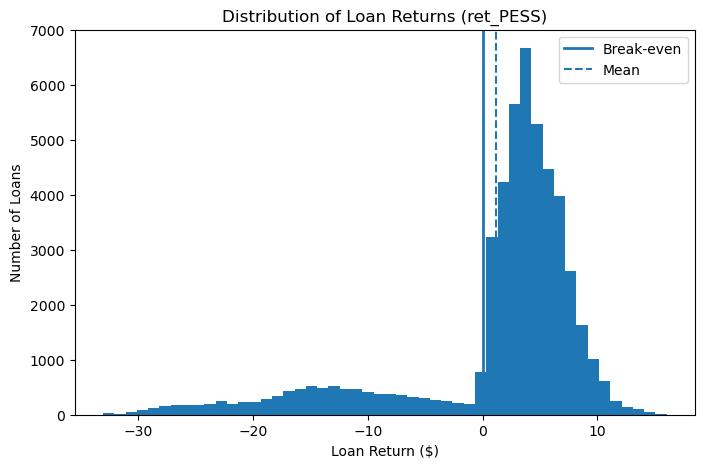

In [82]:
plt.figure(figsize=(8,5))

plt.hist(df['ret_PESS'], bins=50)

plt.axvline(0, linestyle='-', linewidth=2, label='Break-even')
plt.axvline(df['ret_PESS'].mean(), linestyle='--', label='Mean')

plt.xlabel('Loan Return ($)')
plt.ylabel('Number of Loans')
plt.title('Distribution of Loan Returns (ret_PESS)')
plt.legend()

plt.show()

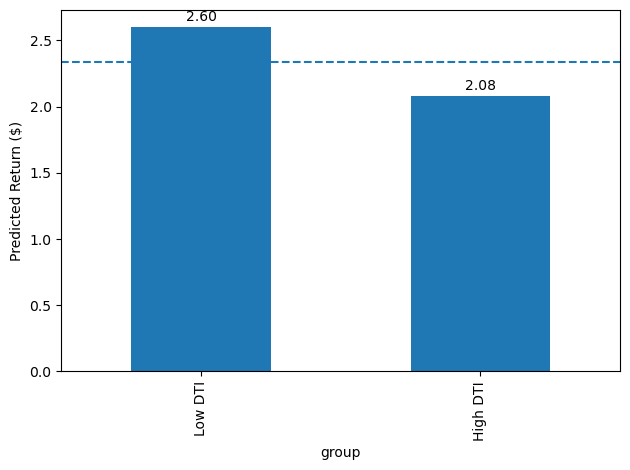

In [92]:
import pandas as pd
import matplotlib.pyplot as plt

# Build dataframe with model predictions
df_plot = pd.DataFrame({
    'dti': test_X['dti'],
    'pred_return': lasso_test_pred
})

# Split into Low vs High DTI (median split)
df_plot['group'] = df_plot['dti'] > df_plot['dti'].median()

# Compute average predicted return per group
summary = df_plot.groupby('group')['pred_return'].mean()

# Plot
plt.figure()
summary.plot(kind='bar')

# Labels
plt.xticks([0, 1], ['Low DTI', 'High DTI'])
plt.ylabel('Predicted Return ($)')


# Add value labels on bars
for i, v in enumerate(summary.values):
    plt.text(i, v + 0.05, f"{v:.2f}", ha='center')

# Add overall mean line (baseline)
plt.axhline(y=df_plot['pred_return'].mean(), linestyle='--')

plt.tight_layout()
plt.show()